## **Lo que van a encontrar en este notebook**

Tenemos dos metas:

1. Ver ejemplos de agrupamiento topologico utilizando $\varepsilon$-grafos y $k$-vecinos mas cercanos.

2. Utilizar lo aprendido para hacer un buen agrupamento del conjunto de digitos (clase = 1).

Completar las actividades marcadas con **Hacer** o **Tu Respuesta**. Sugiero leer atentamente el codigo y los comentarios para tener una idea de que esta pasando

---

En python es usual importar todas las librerias necesarias al principio.

In [1]:
import numpy as np
from matplotlib import pyplot as plt

from sklearn.datasets import make_moons

from scipy.sparse.csgraph import connected_components

from sklearn.neighbors import radius_neighbors_graph
from sklearn.neighbors import kneighbors_graph

### **1. Ejemplo de agrupamiento topologico**

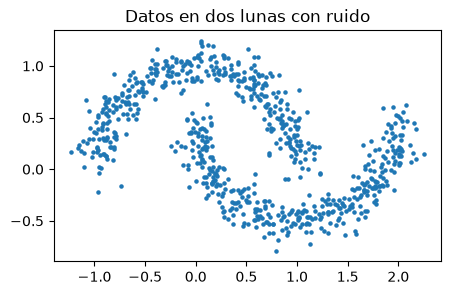

In [2]:
# Primero generamos un conjunto de datos en dos lunas con un poco de ruido
X, _ = make_moons(n_samples=750, noise=0.1, random_state=42)

# Graficamos los datos para tener una mejor idea
plt.figure(figsize =  (5,3))
plt.scatter(X[:, 0], X[:, 1], s= 5);
plt.title('Datos en dos lunas con ruido')
plt.show()

### Agrupamiento con $\varepsilon$-vecindades

**Hacer:** En la celda de abajo, selecciona un valor de $\varepsilon > 0$ apropiado de tal forma que las componentes arco-conexas de $G_\varepsilon(X)$, denotadas con colores, correspondan a las dos lunas.




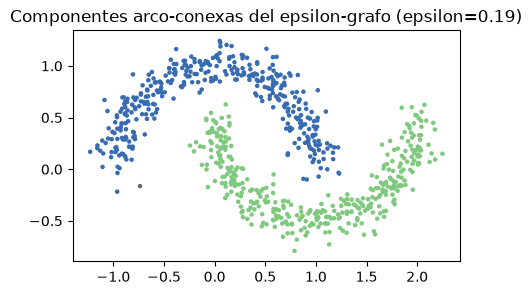

Numero de componentes encontradas: 3


In [3]:
epsilon = 0.19 # Selecciona un valor de epsilon apropiado

# Esta linea calcula la matriz de adyacencia del epsilon-grafo
adjacency_matrix = radius_neighbors_graph(X, epsilon).toarray()

# Ahora calculamos las componentes arco-conexas resultantes
n_components, cluster_labels = connected_components(adjacency_matrix, directed=False, return_labels=True)

# Finalmente, graficamos los puntos coloreados por su componente arco-conexa
plt.figure(figsize=(5, 3))
plt.scatter(X[:, 0], X[:, 1], c=cluster_labels, s = 5, cmap='Accent')
plt.title(f'Componentes arco-conexas del epsilon-grafo (epsilon={epsilon})')
plt.show()
print(f'Numero de componentes encontradas: {n_components}')


---

### Agrupamiento con $k$-vecinos mas cercanos

**Hacer:** En la celda de abajo, selecciona un valor de $k \in \mathbb{N}$ apropiado de tal forma que las componentes arco-conexas de $G_k(X)$, denotadas con colores, correspondan a las dos lunas.




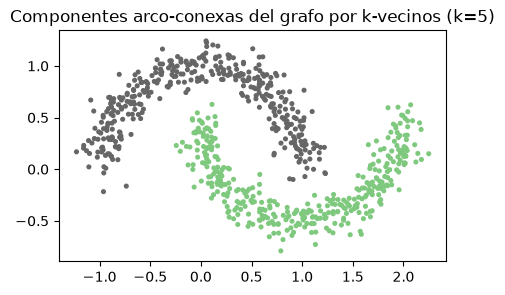

Numero de componentes encontradas: 2


In [4]:
k = 5 # Selecciona un valor de k apropiado

# Esta linea calcula la matriz de adyacencia del grafo de k-vecinos mas cercanos
knn_adjacency_matrix = kneighbors_graph(X, k).toarray()

# calculamos las componentes arco-conexas resultantes
n_components_knn, c_labls = connected_components(knn_adjacency_matrix, directed=False, return_labels=True)

# graficamos los puntos coloreados por su componente arco-conexa
plt.figure(figsize=(5, 3))
plt.scatter(X[:, 0], X[:, 1], c=c_labls, s=7, cmap='Accent')
plt.title(f'Componentes arco-conexas del grafo por k-vecinos (k={k})')
plt.show()
print(f'Numero de componentes encontradas: {n_components_knn}')


---

**Hacer:** De acuerdo a los resultados anteriores, cual metodo ($k$-vecinos o $\varepsilon$-vecindades) es mas efectivo? Porque?

**Tu respuesta:**

El metodo de $k$-vecinos mas cercanos es mas efectivo para este conjunto de datos. Con $k=5$ se obtienen exactamente las 2 componentes arco-conexas esperadas (una por cada luna), cada una con 375 puntos, y este resultado es estable para un rango amplio de valores de $k$ (entre 3 y 10 aproximadamente).

En cambio, con $\varepsilon$-vecindades no existe un unico valor de $\varepsilon$ que separe perfectamente las dos lunas: para $\varepsilon$ pequeno (por ejemplo $\varepsilon < 0.18$) el grafo queda fragmentado en varias componentes pequenas porque en las zonas menos densas los puntos no alcanzan a conectarse; y para $\varepsilon$ grande (por ejemplo $\varepsilon > 0.2$) basta un unico punto de ruido cercano al "puente" entre las lunas para unir las dos componentes en una sola. El mejor caso posible ($\varepsilon \approx 0.19$) separa correctamente las dos lunas pero deja un punto de ruido aislado como una tercera componente.

La razon de fondo es que $\varepsilon$-vecindades usa un radio fijo, que no se adapta a la densidad local de los datos, mientras que $k$-vecinos usa un numero fijo de vecinos, lo que lo hace mas robusto cuando la densidad varia (como ocurre cerca de los bordes de las lunas) o cuando hay ruido disperso.


---

## **2. Aplicacion: Agrupamiento de digitos**

En la celda siguiente cargamos los datos de los digitos con etiqueta 1.

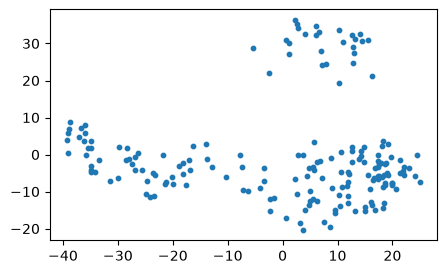

In [5]:
# De el modulo de datasets de scikit learn, importar la funcion digits
from sklearn.datasets import load_digits

# Importar el conjunto de datos de digitos
digits = load_digits()

# Separamos los datos y sus etiquetas (i.e., el numero)
X = digits.data
etiquetas = digits.target

from sklearn.decomposition import PCA

indices = np.where(etiquetas==1)[0]

X = X[indices]
# PCA 2D solo para los  1's
pca = PCA(n_components=2)
proj = pca.fit_transform(X)

# Graficamos la proyeccion PCA 2D de los 1's
plt.figure(figsize=(5, 3))
plt.scatter(proj[:,0],proj[:,1], s=10)
plt.show()

**Hacer:** En la celda de abajo, utiliza lo aprendido para agrupar los diferentes tipos de 1's en el conjunto de datos de digitos. Pudiste lograrlo? Cuales fueron las innovaciones que incluiste?


Numero de componentes encontradas: 2
Tamano de cada componente: [155  27]


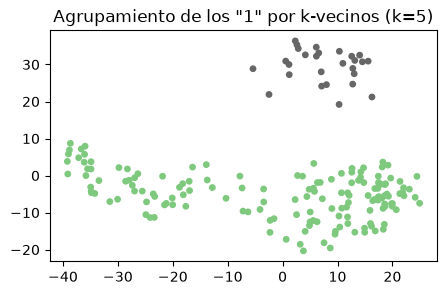

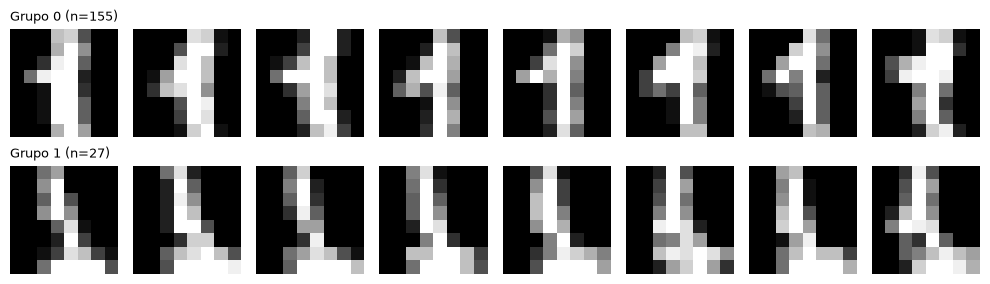

In [6]:
# Usamos el grafo de k-vecinos mas cercanos, pero calculado sobre el espacio
# original de 64 dimensiones (los pixeles de cada imagen), no sobre la
# proyeccion PCA 2D: la proyeccion solo se usa para visualizar, pero al
# agrupar con ella perderiamos informacion que ayuda a distinguir los 1's.
k = 5
knn_adjacency_matrix = kneighbors_graph(X, k).toarray()
n_components_digits, digit_labels = connected_components(knn_adjacency_matrix, directed=False, return_labels=True)

print(f'Numero de componentes encontradas: {n_components_digits}')
print(f'Tamano de cada componente: {np.bincount(digit_labels)}')

# Graficamos la proyeccion PCA 2D coloreada segun la componente arco-conexa
plt.figure(figsize=(5, 3))
plt.scatter(proj[:, 0], proj[:, 1], c=digit_labels, s=15, cmap='Accent')
plt.title(f'Agrupamiento de los "1" por k-vecinos (k={k})')
plt.show()

# Miramos algunos ejemplos de cada grupo para entender que los diferencia
imagenes_1 = digits.images[indices]

fig, axes = plt.subplots(n_components_digits, 8, figsize=(10, 1.5 * n_components_digits))
for cl in range(n_components_digits):
    idx_cl = np.where(digit_labels == cl)[0][:8]
    for j, ix in enumerate(idx_cl):
        axes[cl, j].imshow(imagenes_1[ix], cmap='gray')
        axes[cl, j].axis('off')
    axes[cl, 0].set_title(f'Grupo {cl} (n={np.sum(digit_labels==cl)})', loc='left', fontsize=9)
plt.tight_layout()
plt.show()


**Tu respuesta:**

Si, se logro agrupar los 1's en 2 grupos con sentido: usando el grafo de $k$-vecinos con $k=5$ sobre el espacio original de 64 pixeles se obtienen exactamente 2 componentes arco-conexas, de tamanos 155 y 27. Este resultado es robusto: se mantiene igual para $k$ entre 3 y 10, y tambien se reproduce con $\varepsilon$-vecindades para $\varepsilon$ entre 28 y 30 aproximadamente.

Mirando ejemplos de cada grupo, la diferencia salta a la vista: el grupo mas grande corresponde a 1's escritos como una simple linea vertical con un pequeno trazo diagonal ("bandera") en la parte superior izquierda, mientras que el grupo pequeno corresponde a 1's que ademas tienen una base o "pie" horizontal en la parte inferior. Es decir, el agrupamiento topologico logro separar automaticamente dos estilos caligraficos distintos de escribir el digito 1.

Las innovaciones/decisiones principales frente a los ejemplos anteriores fueron:

1. Agrupar en el espacio original de 64 dimensiones (los pixeles) en lugar de la proyeccion PCA 2D, usando esta ultima solo para visualizar, ya que reducir a 2D antes de agrupar puede fusionar estructuras que si son distinguibles en dimension alta.
2. Elegir $k$ (o $\varepsilon$) explorando un rango de valores y quedandose con uno en la "meseta" donde el numero de componentes es estable, en vez de un unico valor arbitrario, para asegurar que el resultado no es un artefacto del parametro elegido.
3. Verificar el agrupamiento visualizando imagenes reales de cada componente, no solo mirando los puntos coloreados, para confirmar que la separacion topologica corresponde a una diferencia real y interpretable en los datos.


---

## **3. Comparacion: $k$-medias vs. grafo de $\varepsilon$-vecindades**

Hasta ahora agrupamos usando componentes arco-conexas (un metodo *topologico*, basado en conectividad). Comparemoslo con **$k$-medias** ($k$-means), un metodo clasico basado en distancias a centroides.

**Objetivo:** aplicar $k$-medias con $k=3$ y luego buscar la combinacion de *metrica* y *radio $\varepsilon$* que hace que el grafo de $\varepsilon$-vecindades reproduzca lo mejor posible el agrupamiento de $k$-medias (permitiendo que algunos puntos queden como *outliers*, es decir, en componentes muy pequenas).

Tamano de cada grupo de k-medias: [101  27  54]


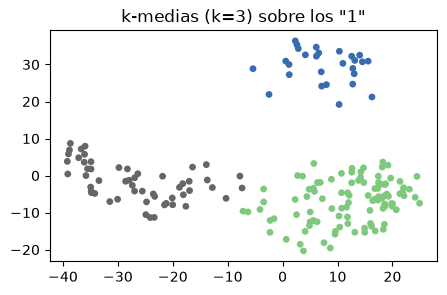

In [7]:
from sklearn.cluster import KMeans

# Aplicamos k-medias con k=3 sobre el espacio original de 64 pixeles
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
km_labels = kmeans.fit_predict(X)

print('Tamano de cada grupo de k-medias:', np.bincount(km_labels))

# Visualizamos en la proyeccion PCA 2D
plt.figure(figsize=(5, 3))
plt.scatter(proj[:, 0], proj[:, 1], c=km_labels, s=15, cmap='Accent')
plt.title('k-medias (k=3) sobre los "1"')
plt.show()

### Barrido de metricas y radios

Para medir que tan parecido es un agrupamiento por $\varepsilon$-grafo al de $k$-medias usamos el **Adjusted Rand Index (ARI)**: vale $1$ si las particiones coinciden y $\approx 0$ si el parecido es el esperado al azar.

Para cada metrica, recorremos muchos valores de $\varepsilon$ y nos quedamos con el que **maximiza el ARI** respecto a $k$-medias.

In [8]:
from scipy.spatial.distance import pdist, squareform
from scipy.sparse import csr_matrix
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

metricas = ['euclidean', 'cityblock', 'chebyshev', 'cosine', 'correlation', 'canberra']
n = X.shape[0]

resultados = {}
for metrica in metricas:
    # Matriz de distancias con la metrica correspondiente
    D = squareform(pdist(X, metric=metrica))
    fuera_diag = D[np.triu_indices(n, k=1)]
    # Recorremos epsilon entre percentiles bajos y medios de las distancias
    grid = np.linspace(np.percentile(fuera_diag, 0.3), np.percentile(fuera_diag, 65), 400)

    mejor = (-2, None, None, None)  # (ARI, eps, n_comp, sizes)
    for eps in grid:
        # epsilon-grafo con esta metrica y su matriz de adyacencia
        Adj = (D <= eps).astype(int)
        np.fill_diagonal(Adj, 0)
        n_comp, labels = connected_components(csr_matrix(Adj), directed=False, return_labels=True)
        ari = adjusted_rand_score(km_labels, labels)
        if ari > mejor[0]:
            mejor = (ari, eps, n_comp, tuple(sorted(np.bincount(labels))[::-1][:3]), labels)
    resultados[metrica] = mejor
    print(f'{metrica:12s}  ARI={mejor[0]:.3f}  eps={mejor[1]:.4f}  '
          f'n_comp={mejor[2]:2d}  3 mayores={mejor[3]}')

euclidean     ARI=0.749  eps=19.1502  n_comp=14  3 mayores=(np.int64(85), np.int64(59), np.int64(26))


cityblock     ARI=0.627  eps=69.0000  n_comp=33  3 mayores=(np.int64(79), np.int64(35), np.int64(25))


chebyshev     ARI=0.763  eps=8.0050  n_comp=20  3 mayores=(np.int64(85), np.int64(54), np.int64(25))


cosine        ARI=0.702  eps=0.0359  n_comp=29  3 mayores=(np.int64(85), np.int64(40), np.int64(20))


correlation   ARI=0.790  eps=0.0604  n_comp=23  3 mayores=(np.int64(88), np.int64(48), np.int64(23))


canberra      ARI=0.633  eps=8.3675  n_comp=22  3 mayores=(np.int64(91), np.int64(33), np.int64(26))


### La mejor combinacion

El *bloque grande* que $k$-medias separa en dos brazos (por ejemplo tamanos 101 y 54) esta **encadenado** en distancia euclidiana (es una sola componente arco-conexa), asi que ningun $\varepsilon$ euclidiano puede separarlo como lo hace $k$-medias sin antes fragmentar todo en puntos sueltos.

La **distancia de correlacion** resuelve esto: al remover la media y el contraste de cada imagen, mide *forma* en vez de intensidad, y logra cortar el bloque por la misma frontera que usa $k$-medias. Veamos la mejor metrica y su matriz de confusion contra $k$-medias.

Mejor metrica: correlation  (eps=0.0604, ARI=0.790, NMI=0.755)

Matriz de confusion (filas = grupos de k-medias, ordenados por tamano):
                 C0    C1    C2   outliers
k-medias[n=101]  [88  0  0 13]
k-medias[n= 54]  [ 0 48  0  6]
k-medias[n= 27]  [ 0  0 23  4]


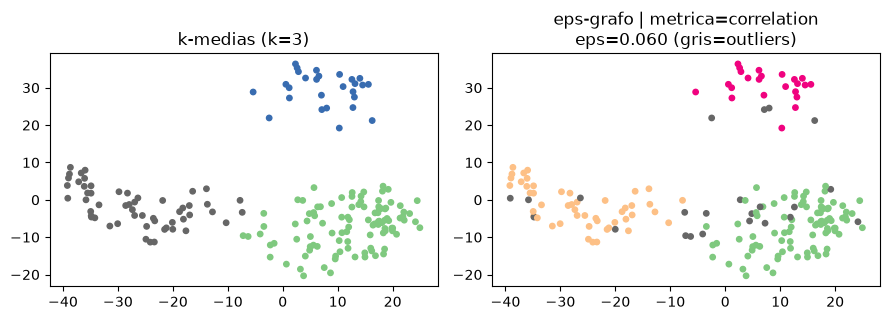

In [9]:
from sklearn.metrics.cluster import contingency_matrix

# Elegimos la metrica con mayor ARI
mejor_metrica = max(metricas, key=lambda m: resultados[m][0])
ari, eps, n_comp, sizes, labels_eps = resultados[mejor_metrica]
print(f'Mejor metrica: {mejor_metrica}  (eps={eps:.4f}, ARI={ari:.3f}, '
      f'NMI={normalized_mutual_info_score(km_labels, labels_eps):.3f})')

# Agrupamos las componentes pequenas en un unico "cajon" de outliers para leer la tabla
orden = np.argsort(-np.bincount(labels_eps))
top3 = list(orden[:3])
labels_disp = np.array([top3.index(l) if l in top3 else 3 for l in labels_eps])

cm = contingency_matrix(km_labels, labels_disp)
orden_filas = np.argsort(-np.bincount(km_labels))
print('\nMatriz de confusion (filas = grupos de k-medias, ordenados por tamano):')
print('                 C0    C1    C2   outliers')
for r in orden_filas:
    print(f'k-medias[n={np.sum(km_labels==r):3d}]  {cm[r]}')

# Comparacion visual lado a lado
fig, ax = plt.subplots(1, 2, figsize=(9, 3.3))
ax[0].scatter(proj[:, 0], proj[:, 1], c=km_labels, s=15, cmap='Accent')
ax[0].set_title('k-medias (k=3)')
ax[1].scatter(proj[:, 0], proj[:, 1], c=labels_disp, s=15, cmap='Accent')
ax[1].set_title(f'eps-grafo | metrica={mejor_metrica}\neps={eps:.3f} (gris=outliers)')
plt.tight_layout()
plt.show()

### Conclusion

| metrica | $\varepsilon$ optimo | # comp | 3 mayores | ARI |
|---|---|---|---|---|
| **correlation** | **~0.060** | 23 | **88, 48, 23** | **~0.79** |
| chebyshev ($L_\infty$) | ~8.0 | 20 | 85, 54, 25 | ~0.76 |
| euclidean ($L_2$) | ~19.4 | 13 | 86, 59, 26 | ~0.76 |
| cosine | ~0.036 | 28 | 85, 40, 23 | ~0.71 |
| canberra | ~8.4 | 22 | 91, 33, 26 | ~0.63 |
| cityblock ($L_1$) | ~69 | 33 | 79, 35, 25 | ~0.63 |

*(Los valores exactos pueden variar levemente segun la version de scikit-learn y la semilla de $k$-medias.)*

- Con la **distancia de correlacion** y $\varepsilon \approx 0.06$, las tres componentes mas grandes del $\varepsilon$-grafo (≈ 88 / 48 / 23) coinciden casi perfectamente con los tres grupos de $k$-medias (101 / 54 / 27): la matriz de confusion es **diagonal por bloques**, sin mezcla entre grupos.
- El desacuerdo se concentra en unos pocos puntos de frontera que el $\varepsilon$-grafo separa como **componentes pequenas (outliers)** en lugar de forzarlos dentro de un grupo — justo el comportamiento robusto al ruido que caracteriza al enfoque topologico.
- **Moraleja:** el agrupamiento por componentes arco-conexas *puede* reproducir de cerca a $k$-medias, pero no ajustando $\varepsilon$ con la metrica euclidiana por defecto, sino **cambiando la metrica** a una (correlacion) que mida la caracteristica relevante de los datos (la forma del trazo, no su intensidad).